Вам представлены данные, которые содержат следующую информацию:

Таблица mkrf_movies содержит информацию из реестра прокатных удостоверений. У одного фильма может быть несколько прокатных удостоверений.

tle — название фильма;

puNumber — номер прокатного удостоверения;

show_start_date — дата премьеры фильма;

type — тип фильма;

film_studio — студия-производитель;

production_country — страна-производитель;

director — режиссёр;

producer — продюсер;

age_restriction — возрастная категория;

refundable_support — объём возвратных средств государственной поддержки;

nonrefundable_support — объём невозвратных средств государственной поддержки;

financing_source — источник государственного финансирования;

budget — общий бюджет фильма;

ratings — рейтинг фильма на КиноПоиске;

genres — жанр фильма



Таблица mkrf_shows содержит сведения о показах фильмов в российских кинотеатрах.

puNumber — номер прокатного удостоверения;

box_office — сборы в рублях.


**Задача:** предсказать рейтинг фильма на КиноПоиске

## Анализ и предобработка данных

* Проанализировать данные (EDA).
* Предобработать данные.
* Скалировать/нормализовать данные.

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
pd.set_option('mode.chained_assignment', None)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_movies = pd.read_csv('/content/drive/My Drive/Магистратура/машинное обучение/mkrf_movies.csv')
df_movies

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама"
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный"
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7481,Сад художника: Американский импрессионизм,126008019,2019-12-23T12:00:00.000Z,Прочие,Севен Артс Продакшнз,Великобритания,Фил Грабски,Фил Грабски,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN
7482,Звериная ярость,121037819,2019-12-24T12:00:00.000Z,Художественный,"Дэниел Гродник Продакшнз, Вандерфилм Медиа Кор...",США,Ник Пауэлл,"Джефф Боулер, Дэниэл Гродник, Луильо Руис, Брэ...",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,5.4,"боевик,триллер"
7483,Щенячий патруль: Скорей спешим на помощь!,124010819,2019-12-28T12:00:00.000Z,Художественный,"Никелодеон Анимейшн Студиос, Спин Мастер",США - Канада,Чарльз Е.Бастьен,Дженнифер Додж,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN
7484,"Машины песенки. Серия ""Испанские мотивы""",124010619,2019-12-30T12:00:00.000Z,Анимационный,"Анимаккорд Лтд., ООО Студия ""АНИМАККОРД""","Республика Кипр, Россия",А.Беляев,Д.Ловейко,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_shows = pd.read_csv('/content/drive/My Drive/Магистратура/машинное обучение/mkrf_shows.csv')
df_shows

,puNumber,box_office
0,111000113,2.450000e+03
1,111000115,6.104000e+04
2,111000116,1.530300e+08
3,111000117,1.226096e+07
4,111000118,1.636841e+08
...,...,...
3153,224014814,1.530000e+03
3154,224021411,9.270000e+03
3155,224022410,4.000000e+02
3156,224023210,3.600000e+02


In [ ]:
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
dtypes: f

In [ ]:
df_shows.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   puNumber    3158 non-null   int64  
 1   box_office  3158 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 49.5 KB


Соединим таблицы в один датафрейм. Соединять будем по puNumber, для этого поменяем тип данных на целочисленный. Для начала посмотрим, есть ли дубликаты.

In [ ]:
df_movies['puNumber'].duplicated().value_counts()

,count
puNumber,
False,7484
True,2


In [ ]:
df_movies['puNumber'].value_counts()

,count
puNumber,
221154310,2
221054410,2
121014411,1
121015211,1
121008811,1
...,...
211047015,1
121011015,1
111005015,1


In [ ]:
df_movies.loc[df_movies['puNumber'] == '221154310']

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
4638,Как жениться и остаться холостым,221154310,2010-12-17T12:00:00.000Z,Художественный,"Ше Вам, Скрипт Ассосье, Тэ Фэ 1 Фильм Продюксь...",Франция,Эрик Лартиго,"Амандин Било, Алан Шаба",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.0,"мелодрама,комедия"
4639,Иоанна - женщина на папском престоле /По роман...,221154310,2010-12-17T12:00:00.000Z,Художественный,"Константин Фильм, А Эр Ди Дегето Фильм, Дюне ...",Германия - Великобритания - Италия - Испания,Зенке Вортманн,"Оливер Бербен, Дорис Д.Хайнце, Фарук Элтан",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.6,"драма,мелодрама,история"


In [ ]:
df_movies.loc[df_movies['puNumber'] == '221054410']

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
5067,Анализируй это!,221054410,2010-05-25T12:00:00.000Z,Художественный,"Уорнер Бразерс, Вилладж Роудшоу Филмз ЛТД",США-Австралия,ХЭрольд Рэмис,"Джейн Розенталь, Пола Уейнстейн",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.4,"комедия,криминал"
5068,Анализируй то!,221054410,2010-05-25T12:00:00.000Z,Художественный,"Уорнер Бразерс, Виллидж Роадшоу Пикчерз, Эн-Пи...",США,Гарольд Реймис,"Джейн Розенталь, Паул Уэйнстейн",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.8,"комедия,криминал"


Удалю по одному фильму

In [ ]:
df_movies = df_movies.drop(index=4639)
df_movies = df_movies.drop(index=5067)

Поменяем тип данных

In [ ]:
# df_movies['puNumber'] = df_movies['puNumber'].astype('int')
# df_movies.info()

Видим ошибку. Уберем "нет"

In [ ]:
df_movies = df_movies.drop(df_movies[df_movies['puNumber'] == 'нет'].index)

Попытаемся снова

In [ ]:
df_movies['puNumber'] = df_movies['puNumber'].astype('int')
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7483 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7483 non-null   object 
 1   puNumber               7483 non-null   int64  
 2   show_start_date        7483 non-null   object 
 3   type                   7483 non-null   object 
 4   film_studio            7465 non-null   object 
 5   production_country     7481 non-null   object 
 6   director               7474 non-null   object 
 7   producer               6915 non-null   object 
 8   age_restriction        7483 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6517 non-null   object 
 14  genres                 6508 non-null   object 
dtypes: float6

Теперь соединим таблицы

In [ ]:
df = pd.merge(df_movies, df_shows, on = 'puNumber', how='left')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7483 entries, 0 to 7482
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7483 non-null   object 
 1   puNumber               7483 non-null   int64  
 2   show_start_date        7483 non-null   object 
 3   type                   7483 non-null   object 
 4   film_studio            7465 non-null   object 
 5   production_country     7481 non-null   object 
 6   director               7474 non-null   object 
 7   producer               6915 non-null   object 
 8   age_restriction        7483 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6517 non-null   object 
 14  genres                 6508 non-null   object 
 15  box_

In [ ]:
df.head(3)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN


Поменяем тип данных в колонке show_start_date

In [ ]:
df['show_start_date'] = pd.to_datetime(df['show_start_date'], format='%Y-%m-%dT%H:%M:%S.%fZ', utc=True)

In [ ]:
df.head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27 12:00:00+00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN


У ratings должно быть какой-то числовой вид. Посмотри, какие вообще значения имеются

In [ ]:
df['ratings'].unique()

array(['7.2', '6.6', '6.8', '7.7', '8.3', '8.0', '7.8', '8.1', '7.1',
       '6.0', '7.4', '5.8', '8.7', '6.3', '6.9', '5.0', '4.3', '7.3',
       '7.0', '6.4', nan, '8.2', '7.5', '6.7', '7.9', '5.9', '6.2', '5.6',
       '6.5', '2.4', '7.6', '6.1', '8.6', '8.5', '8.8', '5.5', '5.1',
       '5.7', '5.4', '99%', '4.4', '4.5', '5.3', '4.1', '8.4', '2.6',
       '3.8', '4.6', '4.8', '4.0', '3.0', '1.6', '4.2', '5.2', '4.7',
       '4.9', '3.9', '2.7', '3.3', '2.9', '28%', '3.7', '1.4', '3.1',
       '97%', '3.5', '3.2', '2.8', '1.5', '2.1', '2.5', '9.2', '3.4',
       '1.1', '3.6', '83%', '64%', '91%', '94%', '62%', '79%', '90%',
       '19%', '88%', '1.0', '89%', '1.3', '1.9', '1.8', '1.2', '1.7',
       '9.0', '98%', '8.9', '9.1'], dtype=object)

Нужно убрать проценты. Скорее всего 99% -> 9.9

In [ ]:
# функция для очистки рейтинга
def clean_rating(value):
  # если это не строка, то пропускаем
  if type(value) != str:
    return None
  # удаляем пробелы на всякий случай
  value = value.strip()
  # если значение заканчивается на процент, то убираем процент и делим на 10
  if value.endswith('%'):
    return float(value[:-1]) / 10

  return float(value)

In [ ]:
df['clean_ratings'] = df['ratings'].apply(clean_rating)

In [ ]:
df['ratings'] = df['clean_ratings']
df = df.drop(columns=['clean_ratings'])

Далее подумаем, что можно сделать с нулевыми значениями

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df.isnull().sum()

,0
title,0
puNumber,0
show_start_date,0
type,0
film_studio,18
production_country,2
director,9
producer,568
age_restriction,0
refundable_support,7151


<BarContainer object of 16 artists>

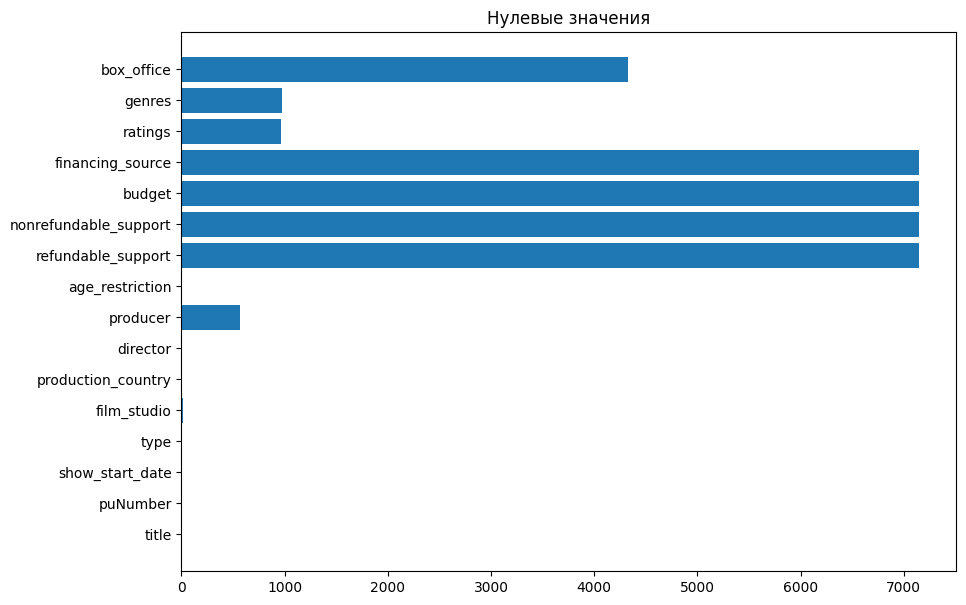

In [ ]:
data = df.isna().sum()

plt.figure(figsize=(10,7))
plt.title('Нулевые значения')
plt.barh(data.index, data.values)

In [ ]:
features = ['film_studio', 'producer', 'refundable_support',
            'nonrefundable_support', 'budget', 'financing_source',
            'ratings', 'genres', 'box_office']

for feature in features:
  na_percentage = round((df[feature].isna().sum() / len(df[feature])) * 100, 3)
  print(f'{na_percentage} % пропущенных данных у признака {feature}')

0.241 % пропущенных данных у признака film_studio
7.591 % пропущенных данных у признака producer
95.563 % пропущенных данных у признака refundable_support
95.563 % пропущенных данных у признака nonrefundable_support
95.563 % пропущенных данных у признака budget
95.563 % пропущенных данных у признака financing_source
12.909 % пропущенных данных у признака ratings
13.03 % пропущенных данных у признака genres
57.798 % пропущенных данных у признака box_office


Очень много пропусков refundable_support, nonrefundable_support, budget и financing_source. Лучше их удалить

При соединении двух таблиц у box_office получилось 4325 пропущенных значений. Оставим пока что

In [ ]:
df = df.drop(columns=['refundable_support', 'nonrefundable_support', 'budget', 'financing_source'])

df

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27 12:00:00+00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,6.8,"фантастика,боевик,триллер",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
7478,Сад художника: Американский импрессионизм,126008019,2019-12-23 12:00:00+00:00,Прочие,Севен Артс Продакшнз,Великобритания,Фил Грабски,Фил Грабски,«12+» - для детей старше 12 лет,NaN,NaN,NaN
7479,Звериная ярость,121037819,2019-12-24 12:00:00+00:00,Художественный,"Дэниел Гродник Продакшнз, Вандерфилм Медиа Кор...",США,Ник Пауэлл,"Джефф Боулер, Дэниэл Гродник, Луильо Руис, Брэ...",«16+» - для детей старше 16 лет,5.4,"боевик,триллер",NaN
7480,Щенячий патруль: Скорей спешим на помощь!,124010819,2019-12-28 12:00:00+00:00,Художественный,"Никелодеон Анимейшн Студиос, Спин Мастер",США - Канада,Чарльз Е.Бастьен,Дженнифер Додж,«0+» - для любой зрительской аудитории,NaN,NaN,NaN
7481,"Машины песенки. Серия ""Испанские мотивы""",124010619,2019-12-30 12:00:00+00:00,Анимационный,"Анимаккорд Лтд., ООО Студия ""АНИМАККОРД""","Республика Кипр, Россия",А.Беляев,Д.Ловейко,«0+» - для любой зрительской аудитории,NaN,NaN,NaN


Обработаем другие пропуски. У film_studio - 0.24%. Можно как-то заполнить.

In [ ]:
df['film_studio'] = df['film_studio'].fillna('Неизвестно')

Также поступим с producer и genres

In [ ]:
df['producer'] = df['producer'].fillna('Неизвестен')
df['genres'] = df['genres'].fillna('Не указано')

Поскольку, ratings - это наша целевая переменная, я не моуг заполнить ее от балды, поэтому удалю строки, которые пропущены

In [ ]:
df = df.dropna(subset='ratings')

In [ ]:
df['ratings'].unique()

array([7.2, 6.6, 6.8, 7.7, 8.3, 8. , 7.8, 8.1, 7.1, 6. , 7.4, 5.8, 8.7,
       6.3, 6.9, 5. , 4.3, 7.3, 7. , 6.4, 8.2, 7.5, 6.7, 7.9, 5.9, 6.2,
       5.6, 6.5, 2.4, 7.6, 6.1, 8.6, 8.5, 8.8, 5.5, 5.1, 5.7, 5.4, 9.9,
       4.4, 4.5, 5.3, 4.1, 8.4, 2.6, 3.8, 4.6, 4.8, 4. , 3. , 1.6, 4.2,
       5.2, 4.7, 4.9, 3.9, 2.7, 3.3, 2.9, 2.8, 3.7, 1.4, 3.1, 9.7, 3.5,
       3.2, 1.5, 2.1, 2.5, 9.2, 3.4, 1.1, 3.6, 9.1, 9.4, 9. , 1.9, 1. ,
       8.9, 1.3, 1.8, 1.2, 1.7, 9.8])

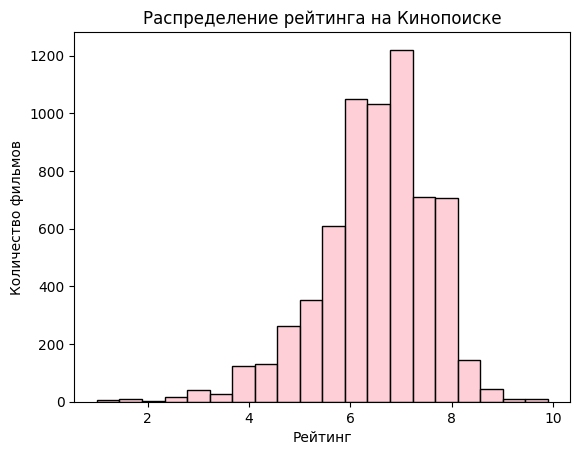

In [ ]:
sns.histplot(df['ratings'], bins=20, color='pink')
plt.title('Распределение рейтинга на Кинопоиске')
plt.xlabel('Рейтинг')
plt.ylabel('Количество фильмов')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6517 entries, 0 to 7482
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   title               6517 non-null   object             
 1   puNumber            6517 non-null   int64              
 2   show_start_date     6517 non-null   datetime64[ns, UTC]
 3   type                6517 non-null   object             
 4   film_studio         6517 non-null   object             
 5   production_country  6515 non-null   object             
 6   director            6514 non-null   object             
 7   producer            6517 non-null   object             
 8   age_restriction     6517 non-null   object             
 9   ratings             6517 non-null   float64            
 10  genres              6517 non-null   object             
 11  box_office          2914 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(2), 

Изначально пропустила production_country и director. Заполню пропуски.

In [ ]:
df['production_country'] = df['production_country'].fillna('Неизвестно')

In [ ]:
df['director'].value_counts()

,count
director,
Стивен Содерберг,17
Ридли Скотт,16
Тиль Швайгер,14
Клинт Иствуд,13
Вуди Аллен,13
...,...
Марк Осборн,1
"Франсуа Бриссон, Жан-Франсуа Пуле",1
Эриксон Кор,1


In [ ]:
df['producer'] = df['producer'].fillna('Не указан')

Посмотрим на дубликаты

In [ ]:
df.duplicated().sum()

np.int64(0)

Переведем всё в нижний регистр

In [ ]:
for column in df.select_dtypes(include=['object']).columns:
  df[column] = df[column].str.lower()

Построим распределения

<ipython-input-40-dc361e4a8b79>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='Set2')


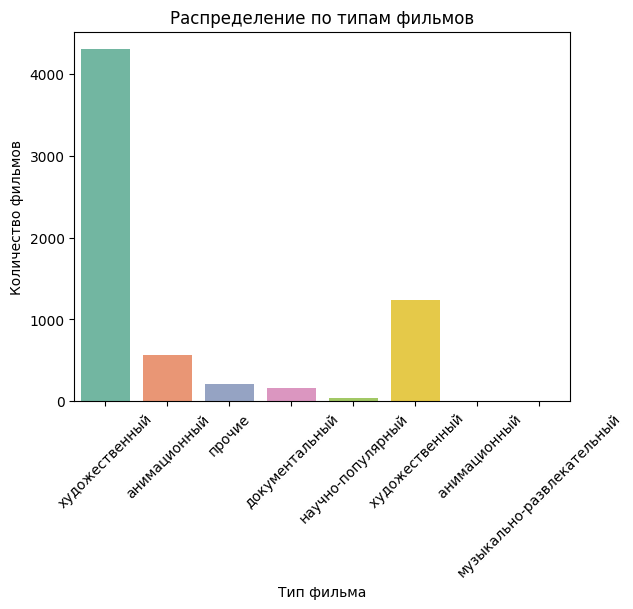

In [ ]:
sns.countplot(data=df, x='type', palette='Set2')
plt.title('Распределение по типам фильмов')
plt.xlabel('Тип фильма')
plt.ylabel('Количество фильмов')
plt.xticks(rotation=45)
plt.show()

Два раза анимационный? Исправим

In [ ]:
df['type'].unique()

array(['художественный', 'анимационный', 'прочие', 'документальный',
       'научно-популярный', ' художественный', ' анимационный',
       'музыкально-развлекательный'], dtype=object)

In [ ]:
df['type'] = df['type'].str.strip()

df['type'].unique()

array(['художественный', 'анимационный', 'прочие', 'документальный',
       'научно-популярный', 'музыкально-развлекательный'], dtype=object)

In [ ]:
df['type'].value_counts()

,count
type,
художественный,5538
анимационный,571
прочие,210
документальный,162
научно-популярный,35
музыкально-развлекательный,1


Посмотрим на страны производители

In [ ]:
df['production_country'].value_counts()

,count
production_country,
сша,2104
россия,1296
ссср,331
франция,289
великобритания,190
...,...
кнр - сша,1
великобритания - австралия - сша,1
"бельгия, канада",1


Разделим их, уберем тире и поменяем на запятые

In [ ]:
df['production_country'] = df['production_country'].str.strip()

In [ ]:
df['production_country'].str.split(r'[-,]').explode().value_counts()

,count
production_country,
сша,2298
россия,1353
франция,412
сша,405
ссср,382
...,...
2019,1
фрация,1
колумбия,1


In [ ]:
df['production_country'] = df['production_country'].str.replace(r'\s*[-,]\s*', ',', regex=True)

Посмотрим на уникальные значения и увидим ошибки. Будем исправлять

In [ ]:
df['production_country'].str.split(r'[-,]').explode().str.strip().unique()

array(['сша', 'ссср', 'франция', 'венгрия', 'германия', 'великобритания',
       'италия', 'чехословакия', 'турция', 'новая зеландия', 'канада',
       'испания', 'мексика', 'россия', 'казахстан', 'швеция', 'англия',
       'куба', 'гдр', 'кнр', 'чсср', 'западный берлин', 'пнр', 'гонконг',
       'япония', 'сингапур', 'таиланд', 'ирландия', 'австралия',
       'финляндия', 'австрия', 'бельгия', 'люксембург', 'нидерланды',
       'чехия', 'польша', 'аргентина', 'бразилия', 'дания', 'швейцария',
       'оаэ', 'израиль', 'индия', 'чили', 'португалия', 'юар', 'исландия',
       'индонезия', 'южная корея', 'украина', 'шри', 'ланка',
       'босния и герцеговина', 'словения', 'сербия', 'норвегия', 'греция',
       'норвения', 'грузия', 'порртугалия', 'хорватия', 'черногория',
       'македония', 'беларусь', 'латвия', 'армения', 'малайзия',
       'колумбия', 'перу', 'румыния', 'болгария', 'изриль', 'пуэрто',
       'рико', 'фрг', 'республика беларусь', 'голландия', 'словакия',
       'мальта

In [ ]:
country_corrections = {
    'сща': 'сша',
    'ссср': 'россия',
    'фрг': 'германия',
    'кнр': 'китай',
    'гдр': 'германия',
    'великобритания ': 'великобритания',
    'англия': 'великобритания',
    'чсср': 'россия',
    'западный берлин': 'германия',
    'гонконг': 'китай',
    'юар': 'южноафриканская республика',
    'пуэрто': 'пуэрто рико',
    'рико': 'пуэрто рико',
    'республика беларусь': 'беларусь',
    'голландия': 'нидерланды',
    'бенльгия': 'бельгия',
    'ю.корея': 'южная корея',
    'республика кипр': 'кипр',
    'к;анада': 'канада',
    'корея': 'южная корея',
    'белоруссия': 'беларусь',
    'босния': 'босния и герцеговина',
    'герцеговина': 'босния и герцеговина',
    'объединенные арабские эмираты': 'оаэ',
    'чешская республика': 'чехия',
    '2019': 'неизвестно',
    'фрация': 'франция',
}

df['production_country'] = df['production_country'].apply(
    lambda x: ', '.join([country_corrections.get(country.strip(), country) for country in x.split(',')])
)

In [ ]:
# применим исправления
df['production_country'] = df['production_country'].apply(
    lambda x: country_corrections.get(x.lower(), x)
)

# объединяем строки в нужный формат
df['production_country'] = df['production_country'].groupby(df.index).transform(lambda x: ', '.join(x))

In [ ]:
df['production_country'].str.split(r'[-,]').explode().str.strip().unique()

array(['сша', 'россия', 'франция', 'венгрия', 'германия',
       'великобритания', 'италия', 'чехословакия', 'турция',
       'новая зеландия', 'канада', 'испания', 'мексика', 'казахстан',
       'швеция', 'куба', 'китай', 'пнр', 'япония', 'сингапур', 'таиланд',
       'ирландия', 'австралия', 'финляндия', 'австрия', 'бельгия',
       'люксембург', 'нидерланды', 'чехия', 'польша', 'аргентина',
       'бразилия', 'дания', 'швейцария', 'оаэ', 'израиль', 'индия',
       'чили', 'португалия', 'южноафриканская республика', 'исландия',
       'индонезия', 'южная корея', 'украина', 'шри', 'ланка',
       'босния и герцеговина', 'словения', 'сербия', 'норвегия', 'греция',
       'норвения', 'грузия', 'порртугалия', 'хорватия', 'черногория',
       'македония', 'беларусь', 'латвия', 'армения', 'малайзия',
       'колумбия', 'перу', 'румыния', 'болгария', 'изриль', 'пуэрто рико',
       'словакия', 'мальта', 'кипр', 'афганистан', 'азербайджан',
       'парагвай', 'уругвай', 'иран', 'германя', 'э

In [ ]:
df['production_country'].unique()

array(['сша', 'россия', 'франция', 'россия, венгрия',
       'германия, великобритания', 'великобритания, италия',
       'чехословакия', 'сша, франция, турция', 'новая зеландия',
       'канада, франция, испания', 'сша, германия', 'сша, великобритания',
       'великобритания', 'франция, мексика, сша',
       'россия, казахстан, сша', 'россия, швеция',
       'россия, франция, великобритания, куба, германия', 'германия',
       'великобритания, сша, германия, китай',
       'россия, россия, германия, пнр', 'россия, италия', 'китай, китай',
       'сша, франция', 'сша, япония, франция, великобритания',
       'китай, сингапур, таиланд, великобритания', 'сша, канада',
       'франция, италия, великобритания, сша', 'франция, сша',
       'ирландия, великобритания, германия', 'сша, австралия',
       'россия, финляндия', 'сша, франция, великобритания, австрия',
       'сша, бельгия', 'сша, ирландия, великобритания',
       'великобритания, сша',
       'люксембург, нидерланды, испания, ве

Так и оставим

Посмотрим на жанры

In [ ]:
df['genres'].value_counts()

,count
genres,
драма,476
комедия,352
"мелодрама,комедия",222
"драма,мелодрама,комедия",189
"драма,мелодрама",183
...,...
"ужасы,драма,военный",1
"фэнтези,драма,ужасы",1
"комедия,детектив,приключения",1


In [ ]:
df['genres'].str.split(r'[-,]').explode().str.strip().unique()

array(['боевик', 'драма', 'мелодрама', 'военный', 'фантастика', 'триллер',
       'комедия', 'мюзикл', 'криминал', 'детектив', 'приключения',
       'спорт', 'история', 'семейный', 'ужасы', 'мультфильм',
       'короткометражка', 'фэнтези', 'биография', 'документальный',
       'детский', 'музыка', 'вестерн', 'аниме', 'для взрослых', 'концерт',
       'не указано', 'фильм', 'нуар', 'новости', 'реальное тв'],
      dtype=object)

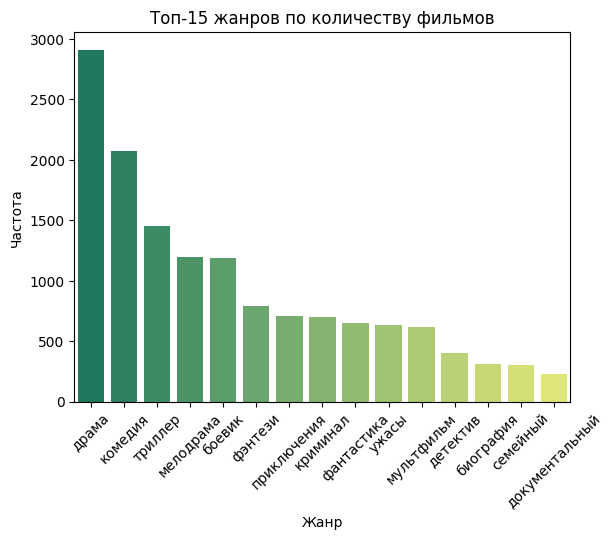

In [ ]:
genre_counts = df['genres'].str.split(',').explode().value_counts().head(15)
sns.barplot(x=genre_counts.index, y=genre_counts.values, hue=genre_counts.index, palette='summer')
plt.title('Топ-15 жанров по количеству фильмов')
plt.xlabel('Жанр')
plt.ylabel('Частота')
plt.xticks(rotation=45)
plt.show()

Посмотрим на возрастные категории

In [ ]:
df['age_restriction'].unique()

array(['«18+» - запрещено для детей', '«6+» - для детей старше 6 лет',
       '«12+» - для детей старше 12 лет',
       '«16+» - для детей старше 16 лет',
       '«0+» - для любой зрительской аудитории'], dtype=object)

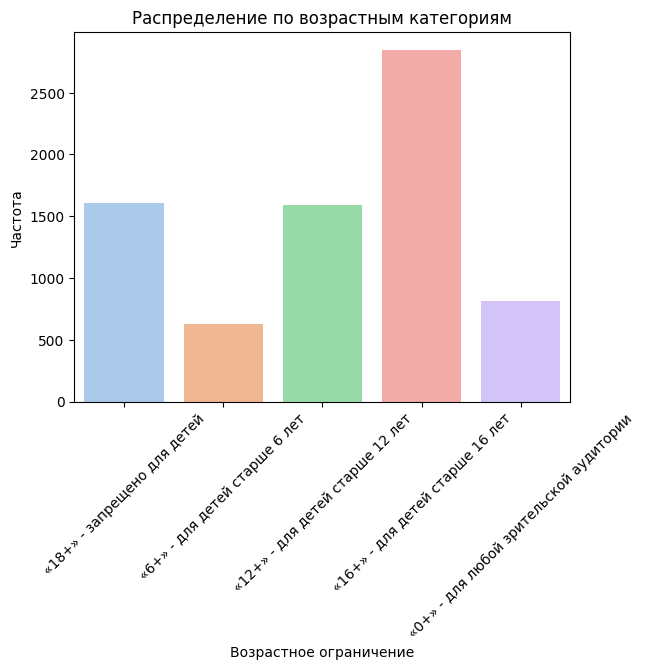

In [ ]:
sns.countplot(data=df_movies, x='age_restriction', hue='age_restriction', palette='pastel')
plt.title('Распределение по возрастным категориям')
plt.xlabel('Возрастное ограничение')
plt.ylabel('Частота')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df['director'].unique()

array(['кевин костнер', 'е.матвеев', 'тимур бекмамбетов', ...,
       'м.бальчюнас (псевдоним м.вайсберг)', 'ник пауэлл', 'и.трусов'],
      dtype=object)

In [ ]:
df['producer'].unique()

array(['дэвид валдес, кевин костнер, джейк эбертс', 'неизвестен',
       'джим лемли, джейсон нетер, марк е.платт, яйн смит', ...,
       'джейлан атаман-джека',
       'с.мелькумов, а.роднянский, м.вайсберг, р.минасбекян',
       'джефф боулер, дэниэл гродник, луильо руис, брэт саксон, кирк шоу'],
      dtype=object)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6517 entries, 0 to 7482
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   title               6517 non-null   object             
 1   puNumber            6517 non-null   int64              
 2   show_start_date     6517 non-null   datetime64[ns, UTC]
 3   type                6517 non-null   object             
 4   film_studio         6517 non-null   object             
 5   production_country  6517 non-null   object             
 6   director            6514 non-null   object             
 7   producer            6517 non-null   object             
 8   age_restriction     6517 non-null   object             
 9   ratings             6517 non-null   float64            
 10  genres              6517 non-null   object             
 11  box_office          2914 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(2), 

In [ ]:
categorical_columns = ['type','production_country',
           'director', 'producer', 'age_restriction',
           'genres', 'film_studio']
for column in categorical_columns:
    display(pd.DataFrame(df[column].value_counts().head(5)))

,count
type,
художественный,5538
анимационный,571
прочие,210
документальный,162
научно-популярный,35


,count
production_country,
сша,2108
россия,1657
франция,290
великобритания,192
"сша, великобритания",105


,count
director,
стивен содерберг,17
ридли скотт,16
тиль швайгер,14
питер джексон,13
вуди аллен,13


,count
producer,
неизвестен,478
с.сельянов,18
кевин фейги,11
тони майерс,11
п.смирнов,11


,count
age_restriction,
«16+» - для детей старше 16 лет,2661
«18+» - запрещено для детей,1512
«12+» - для детей старше 12 лет,1348
«6+» - для детей старше 6 лет,528
«0+» - для любой зрительской аудитории,468


,count
genres,
драма,476
комедия,352
"мелодрама,комедия",222
"драма,мелодрама,комедия",189
"драма,мелодрама",183


,count
film_studio,
"киностудия ""мосфильм""",331
"ооо ""студия анимационного кино ""мельница""",13
"ооо ""таббак""",12
"ооо ""кинокомпания ""ств""",12
"ооо ""мульт в кино""",11


Попробуем разобраться с категориальными признаками. Так как age_restriction логично упорядочен, то закодируем как число

In [ ]:
age_map = {
    '«0+» - для любой зрительской аудитории	': 0,
    '«6+» - для детей старше 6 лет': 6,
    '«12+» - для детей старше 12 лет': 12,
    '«16+» - для детей старше 16 лет': 16,
    '«18+» - запрещено для детей': 18
}

df['age_restriction'] = df['age_restriction'].map(age_map)

Для type используем One-Hot Encoding

In [ ]:
df = pd.get_dummies(df, columns=['type'], prefix='type')

Попробуем для категориальных признаков, где много значений использовать Embedding

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le_director = LabelEncoder()
df['director_encoded'] = le_director.fit_transform(df['director'].fillna('неизвестно'))

In [ ]:
le_production_country = LabelEncoder()
df['production_country_encoded'] = le_production_country.fit_transform(df['production_country'].fillna('неизвестно'))

In [ ]:
le_film_studio = LabelEncoder()
df['film_studio_encoded'] = le_film_studio.fit_transform(df['film_studio'].fillna('неизвестно'))

Для production_country оставим топ стран, а остальные перенесем в другое

In [ ]:
top_countries = df['production_country'].value_counts().nlargest(5).index

In [ ]:
def simplify_country(val):
    if pd.isna(val):
        return 'другое'
    for country in top_countries:
        if country in val.lower():
            return country
    return 'другое'

df['production_country_simplified'] = df['production_country'].apply(simplify_country)


Для genres воспользуемся MultiLabelBinarizer

In [ ]:
df['genres'].str.split(',').explode().value_counts()

,count
genres,
драма,2911
комедия,2074
триллер,1455
мелодрама,1200
боевик,1188
фэнтези,792
приключения,708
криминал,699
фантастика,653


In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

In [ ]:
df['genres_list'] = df['genres'].str.lower().str.split(',')

mlb = MultiLabelBinarizer()
genres_encoded = mlb.fit_transform(df['genres_list'])

In [ ]:
genres_df = pd.DataFrame(genres_encoded, columns=mlb.classes_)

In [ ]:
df = pd.concat([df, genres_df], axis=1)

In [ ]:
df['age_restriction'] = df['age_restriction'].fillna(df['age_restriction'].mode()[0])

In [ ]:
df['box_office'] = df['box_office'].fillna(df['box_office'].median())

### Теперь нужно скалировать|нормализовать данные.

Нормализуем рейтинг

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()
df['ratings'] = scaler.fit_transform(df[['ratings']])

In [ ]:
scaler_bo = MinMaxScaler()
df['box_office'] = scaler.fit_transform(df[['box_office']])

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
df=df.drop(columns=['title'])

In [ ]:
df = df.drop(columns=['production_country_simplified', 'film_studio', 'production_country', 'director', 'producer', 'genres', 'genres_list', 'show_start_date'])


In [ ]:
df = df.dropna()

In [ ]:
boolean_columns = [
    'type_анимационный',
    'type_документальный',
    'type_музыкально-развлекательный',
    'type_научно-популярный',
    'type_прочие',
    'type_художественный'
]
df[boolean_columns] = df[boolean_columns].replace({'True': 1, 'False': 0}).astype(int)
df[boolean_columns].head()

<ipython-input-84-ca1583586af5>:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[boolean_columns] = df[boolean_columns].replace({'True': 1, 'False': 0}).astype(int)


,type_анимационный,type_документальный,type_музыкально-развлекательный,type_научно-популярный,type_прочие,type_художественный
0,0,0,0,0,0,1
1,0,0,0,0,0,1
2,0,0,0,0,0,1
3,0,0,0,0,0,1
4,0,0,0,0,0,1


In [ ]:
X = df.drop(columns=['ratings'])
y = df['ratings']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5773 entries, 0 to 6512
Data columns (total 43 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   puNumber                         5773 non-null   float64
 1   age_restriction                  5773 non-null   float64
 2   ratings                          5773 non-null   float64
 3   box_office                       5773 non-null   float64
 4   type_анимационный                5773 non-null   int64  
 5   type_документальный              5773 non-null   int64  
 6   type_музыкально-развлекательный  5773 non-null   int64  
 7   type_научно-популярный           5773 non-null   int64  
 8   type_прочие                      5773 non-null   int64  
 9   type_художественный              5773 non-null   int64  
 10  director_encoded                 5773 non-null   float64
 11  production_country_encoded       5773 non-null   float64
 12  film_studio_encoded      

## Построение простой модели нейронной сети — baseline

* Создайте класс для задания архитектуры нейронной сети.
* Самостоятельно выберите количество скрытых слоев, количество нейронов на них, функции активации на скрытых и выходном слоях. Попробуйте и сравните несколько подобных комбинаций.
* Создайте функцию для обучения нейронной сети.
* Проведите обучение модели.
* Постройте гистограмму «Факт — Прогноз», чтобы наглядно увидеть, как сильно модель ошибается.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

Создадим класс для задания архитектуры нейронной сети.

In [ ]:
class MovieRatingNN(nn.Module):
    def __init__(self, num_numeric_features, num_genres, num_directors, num_countries, num_studios):
        super(MovieRatingNN, self).__init__()

        self.director_emb = nn.Embedding(num_directors, 8)
        self.country_emb = nn.Embedding(num_countries, 8)
        self.studio_emb = nn.Embedding(num_studios, 8)

        self.fc1 = nn.Linear(num_numeric_features + 24, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x_num, x_genres, x_director, x_country, x_studio):
        director_emb = self.director_emb(x_director.long())
        country_emb = self.country_emb(x_country.long())
        studio_emb = self.studio_emb(x_studio.long())

        x = torch.cat([x_num, x_genres, director_emb, country_emb, studio_emb], dim=1)

        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.dropout(self.relu(self.fc3(x)))
        x = self.fc4(x)

        return x

In [ ]:
numeric_features = ['box_office', 'age_restriction']
genre_features = [col for col in df.columns if col not in numeric_features +
                  ['puNumber', 'ratings', 'director_encoded', 'production_country_encoded', 'film_studio_encoded']]

In [ ]:
class MovieDataset(Dataset):
    def __init__(self, df):
        self.numeric = torch.tensor(df[numeric_features].values, dtype=torch.float32)
        self.genres = torch.tensor(df[genre_features].values, dtype=torch.float32)
        self.director = torch.tensor(df['director_encoded'].values, dtype=torch.long)
        self.country = torch.tensor(df['production_country_encoded'].values, dtype=torch.long)
        self.studio = torch.tensor(df['film_studio_encoded'].values, dtype=torch.long)
        self.ratings = torch.tensor(df['ratings'].values, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return (self.numeric[idx],
                self.genres[idx],
                self.director[idx],
                self.country[idx],
                self.studio[idx],
                self.ratings[idx])


In [ ]:
train_df = df.sample(frac=0.8, random_state=42)
val_df = df.drop(train_df.index)

In [ ]:
train_dataset = MovieDataset(train_df)
val_dataset = MovieDataset(val_df)

In [ ]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

In [ ]:
model = MovieRatingNN(
    num_numeric_features=len(numeric_features) + len(genre_features),
    num_genres=len(genre_features),
    num_directors=int(df['director_encoded'].max()) + 1,
    num_countries=int(df['production_country_encoded'].max()) + 1,
    num_studios=int(df['film_studio_encoded'].max()) + 1
)

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [ ]:
def train_model(model, train_loader, val_loader, epochs=10):
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            x_num, x_genres, x_dir, x_country, x_studio, y = batch
            optimizer.zero_grad()
            outputs = model(x_num, x_genres, x_dir, x_country, x_studio)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                x_num, x_genres, x_dir, x_country, x_studio, y = batch
                outputs = model(x_num, x_genres, x_dir, x_country, x_studio)
                val_loss += criterion(outputs, y).item()

        print(f'Epoch {epoch+1}/{epochs} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}')

In [ ]:
train_model(model, train_loader, val_loader, epochs=250)

Epoch 1/250 | Train Loss: 0.0972 | Val Loss: 0.0232
Epoch 2/250 | Train Loss: 0.0398 | Val Loss: 0.0224
Epoch 3/250 | Train Loss: 0.0320 | Val Loss: 0.0194
Epoch 4/250 | Train Loss: 0.0294 | Val Loss: 0.0179
Epoch 5/250 | Train Loss: 0.0289 | Val Loss: 0.0159
Epoch 6/250 | Train Loss: 0.0265 | Val Loss: 0.0155
Epoch 7/250 | Train Loss: 0.0236 | Val Loss: 0.0157
Epoch 8/250 | Train Loss: 0.0231 | Val Loss: 0.0157
Epoch 9/250 | Train Loss: 0.0220 | Val Loss: 0.0153
Epoch 10/250 | Train Loss: 0.0208 | Val Loss: 0.0157
Epoch 11/250 | Train Loss: 0.0201 | Val Loss: 0.0166
Epoch 12/250 | Train Loss: 0.0194 | Val Loss: 0.0160
Epoch 13/250 | Train Loss: 0.0185 | Val Loss: 0.0144
Epoch 14/250 | Train Loss: 0.0186 | Val Loss: 0.0146
Epoch 15/250 | Train Loss: 0.0174 | Val Loss: 0.0145
Epoch 16/250 | Train Loss: 0.0172 | Val Loss: 0.0153
Epoch 17/250 | Train Loss: 0.0160 | Val Loss: 0.0144
Epoch 18/250 | Train Loss: 0.0158 | Val Loss: 0.0151
Epoch 19/250 | Train Loss: 0.0152 | Val Loss: 0.0144
Ep

Сделаем визуализацию

In [ ]:
model.eval()
predictions = []
true_values = []

with torch.no_grad():
    for batch in val_loader:
        x_num, x_genres, x_dir, x_country, x_studio, y = batch
        outputs = model(x_num, x_genres, x_dir, x_country, x_studio)
        predictions.extend(outputs.squeeze().tolist())
        true_values.extend(y.squeeze().tolist())

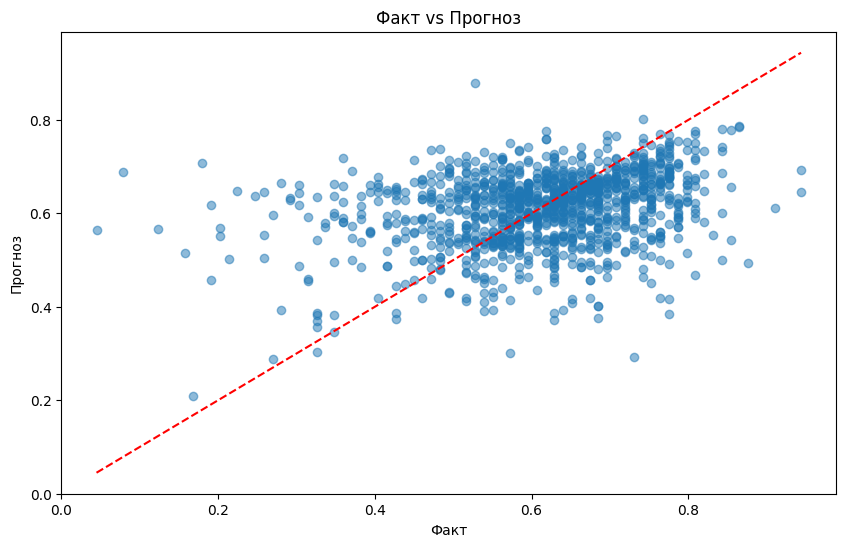

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(true_values, predictions, alpha=0.5)
plt.xlabel('Факт')
plt.ylabel('Прогноз')
plt.title('Факт vs Прогноз')
plt.plot([min(true_values), max(true_values)], [min(true_values), max(true_values)], 'r--')
plt.show()

## Улучшение модели

* Создайте решение с перебором параметров нейросети и обучения. Список параметров для перебора должен включать как минимум выбор функции активации, наличие/значение dropout, наличие нормализации и размер батча. Архитектуру нейронной сети, количество слоев и нейронов оставьте как в Baseline, чтобы сравнить результат.
* Проведите обучение. Постройте графики зависимости значений подбираемых параметров и значения метрики RMSE.
* Выберите лучшую модель и постройте гистограмму «Факт — прогноз».
* Сделайте вывод.

In [ ]:
param_grid = {
    'activation': ['relu', 'leaky_relu', 'elu', 'tanh'],
    'dropout': [0.0, 0.1, 0.2, 0.3],
    'batch_norm': [True, False],
    'batch_size': [32, 64, 128]
}

In [ ]:
class EnhancedMovieRatingNN(nn.Module):
    def __init__(self, num_numeric_features, num_genres, num_directors, num_countries,
                 num_studios, activation='relu', dropout=0.2, batch_norm=False):
        super(EnhancedMovieRatingNN, self).__init__()

        self.director_emb = nn.Embedding(num_directors, 8)
        self.country_emb = nn.Embedding(num_countries, 8)
        self.studio_emb = nn.Embedding(num_studios, 8)

        if activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'leaky_relu':
            self.activation = nn.LeakyReLU(0.1)
        elif activation == 'elu':
            self.activation = nn.ELU()
        elif activation == 'tanh':
            self.activation = nn.Tanh()

        self.fc1 = nn.Linear(num_numeric_features + 24, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(dropout)
        self.batch_norm = batch_norm
        if batch_norm:
            self.bn1 = nn.BatchNorm1d(128)
            self.bn2 = nn.BatchNorm1d(64)
            self.bn3 = nn.BatchNorm1d(32)

    def forward(self, x_num, x_genres, x_director, x_country, x_studio):
        director_emb = self.director_emb(x_director.long())
        country_emb = self.country_emb(x_country.long())
        studio_emb = self.studio_emb(x_studio.long())

        x = torch.cat([x_num, x_genres, director_emb, country_emb, studio_emb], dim=1)

        x = self.fc1(x)
        if self.batch_norm:
            x = self.bn1(x)
        x = self.activation(x)
        x = self.dropout(x)

        x = self.fc2(x)
        if self.batch_norm:
            x = self.bn2(x)
        x = self.activation(x)
        x = self.dropout(x)

        x = self.fc3(x)
        if self.batch_norm:
            x = self.bn3(x)
        x = self.activation(x)
        x = self.dropout(x)

        x = self.fc4(x)
        return x


In [ ]:
def train_and_evaluate(params, train_df, val_df, num_numeric_features, num_genres,
                      num_directors, num_countries, num_studios, epochs=15):
    batch_size = params['batch_size']
    train_loader = DataLoader(MovieDataset(train_df), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(MovieDataset(val_df), batch_size=batch_size)

    model = EnhancedMovieRatingNN(
        num_numeric_features=num_numeric_features,
        num_genres=num_genres,
        num_directors=num_directors,
        num_countries=num_countries,
        num_studios=num_studios,
        activation=params['activation'],
        dropout=params['dropout'],
        batch_norm=params['batch_norm']
    )

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            x_num, x_genres, x_dir, x_country, x_studio, y = batch
            optimizer.zero_grad()
            outputs = model(x_num, x_genres, x_dir, x_country, x_studio)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Валидация
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                x_num, x_genres, x_dir, x_country, x_studio, y = batch
                outputs = model(x_num, x_genres, x_dir, x_country, x_studio)
                val_loss += criterion(outputs, y).item()

        train_losses.append(train_loss/len(train_loader))
        val_losses.append(val_loss/len(val_loader))

    final_rmse = np.sqrt(np.mean(val_losses[-3:]))
    return final_rmse, model, train_losses, val_losses


In [ ]:
num_numeric_features = len(numeric_features) + len(genre_features)
num_genres = len(genre_features)
num_directors = int(df['director_encoded'].max()) + 1
num_countries = int(df['production_country_encoded'].max()) + 1
num_studios = int(df['film_studio_encoded'].max()) + 1

In [ ]:
results = []
best_rmse = float('inf')
best_model = None
best_params = None

In [ ]:
from itertools import product
from tqdm import tqdm

In [ ]:
param_combinations = list(product(*param_grid.values()))
param_names = list(param_grid.keys())

In [ ]:
print('Начинаем поиск параметров...')
for param_values in tqdm(param_combinations):
    params = dict(zip(param_names, param_values))

    try:
        rmse, model, train_losses, val_losses = train_and_evaluate(
            params, train_df, val_df,
            num_numeric_features, num_genres,
            num_directors, num_countries, num_studios,
            epochs=15
        )

        results.append({
            'params': params,
            'rmse': rmse,
            'train_losses': train_losses,
            'val_losses': val_losses
        })

        if rmse < best_rmse:
            best_rmse = rmse
            best_model = model
            best_params = params
            print(f'Новая лучшая модель: RMSE = {best_rmse:.4f}, параметры: {best_params}')

    except Exception as e:
        print(f'Ошибка при параметрах {params}: {str(e)}')
        continue

print('Закончили поиск параметров!!!!!')

Начинаем поиск параметров...


  1%|          | 1/96 [00:14<22:14, 14.04s/it]

Новая лучшая модель: RMSE = 0.1301, параметры: {'activation': 'relu', 'dropout': 0.0, 'batch_norm': True, 'batch_size': 32}


  5%|▌         | 5/96 [00:46<12:41,  8.37s/it]

Новая лучшая модель: RMSE = 0.1264, параметры: {'activation': 'relu', 'dropout': 0.0, 'batch_norm': False, 'batch_size': 64}


...

Новая лучшая модель: RMSE = 0.1166, параметры: {'activation': 'elu', 'dropout': 0.1, 'batch_norm': True, 'batch_size': 128}


 81%|████████▏ | 78/96 [09:33<01:38,  5.47s/it]

Новая лучшая модель: RMSE = 0.1155, параметры: {'activation': 'tanh', 'dropout': 0.0, 'batch_norm': False, 'batch_size': 128}


100%|██████████| 96/96 [11:25<00:00,  7.14s/it]

Закончили поиск параметров!!!!!


In [ ]:
def plot_param_influence(results, param_name):
    param_values = []
    rmses = []

    for result in results:
        param_values.append(result['params'][param_name])
        rmses.append(result['rmse'])

    # для категориальных
    if isinstance(param_values[0], str) or isinstance(param_values[0], bool):
        unique_values = list(set(param_values))
        avg_rmses = [np.mean([r for p, r in zip(param_values, rmses) if p == v]) for v in unique_values]

        plt.figure(figsize=(10, 6))
        if isinstance(unique_values[0], bool):
            labels = ['Нет', 'Да'] if unique_values[0] is False else ['Да', 'Нет']
            plt.bar(labels, avg_rmses, color='pink')
        else:
            plt.bar(unique_values, avg_rmses, color='green')
        plt.title(f'Влияние параметра "{param_name}" на RMSE')
        plt.xlabel(param_name)
        plt.ylabel('Среднее значение RMSE')
        plt.grid(True)
    else:
        plt.figure(figsize=(10, 6))
        plt.scatter(param_values, rmses, alpha=0.5, color='orange')
        plt.title(f'Влияние параметра "{param_name}" на RMSE')
        plt.xlabel(param_name)
        plt.ylabel('RMSE')
        plt.grid(True)

    plt.show()

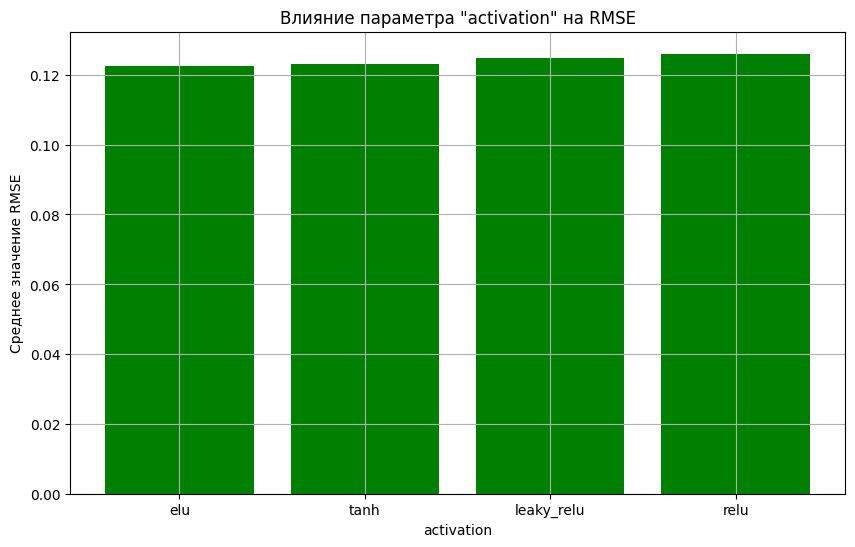

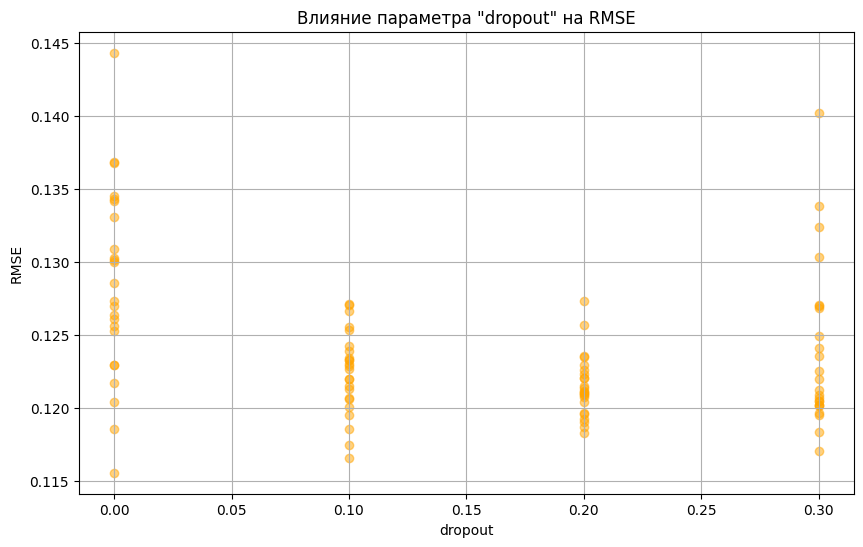

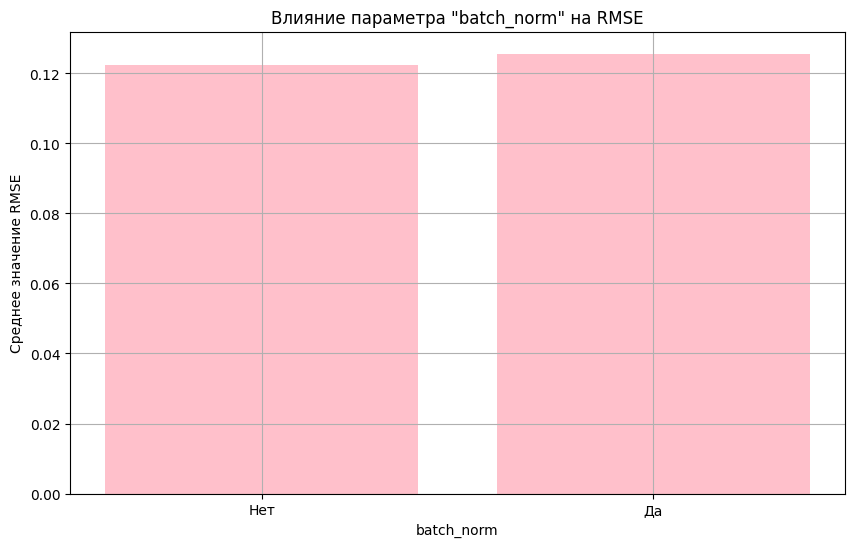

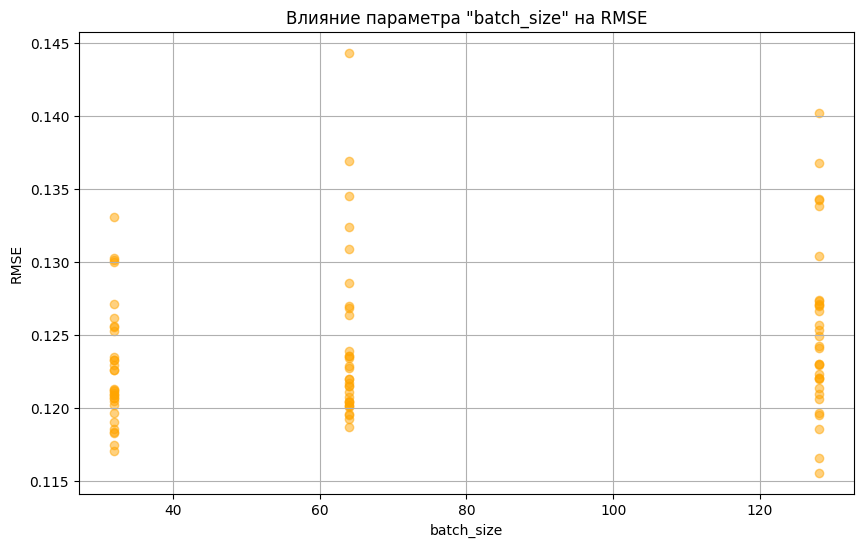

In [ ]:
plot_param_influence(results, 'activation')
plot_param_influence(results, 'dropout')
plot_param_influence(results, 'batch_norm')
plot_param_influence(results, 'batch_size')

Выводы:

Влияние параметра activation на RMSE:

Наименьшее среднее значение RMSE показывает elu, за ним идет tanh. Различия между функциями активации незначительны

Влияние параметра dropout на RMSE:

При увеличении dropout от 0.0 до 0.3 разброс RMSE уменьшается. Оптимальными значениями кажутся 0.2 и 0.3.

Влияние параметра batch_norm на RMSE:

Видно, что разница в RMSE между двумя вариантами минимальна.

Влияние параметра batch_size на RMSE:

batch_size = 64 показывает наилучшие результаты. Большинство точек при 64 имеют наименьшие значения RMSE. batch_size = 32 немного хуже. batch_size = 128 — наихудший результат
